<a href="https://colab.research.google.com/github/samiraQS/AI-ML-ENG-/blob/main/AI_ML_ENG_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance scikit-learn pandas matplotlib

## Importing Libraries

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Downloading stock data

In [4]:
stock = yf.download('AAPL', start='2020-01-01', end='2025-01-01') #We use Apple's stock (AAPL) as an example. Data includes Open, High, Low, Close, and Volume.
print(stock.head()) #to display first five rows of dataset

/tmp/ipykernel_551/291058796.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download('AAPL', start='2020-01-01', end='2025-01-01') #We use Apple's stock (AAPL) as an example. Data includes Open, High, Low, Close, and Volume.
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333878  72.394086  71.091184  71.344054  135480400
2020-01-03  71.630646  72.389265  71.406674  71.563213  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861839  72.466322  71.642681  72.211041  108872000
2020-01-08  73.017822  73.318862  71.565606  71.565606  132079200


## Prepare data using open, high, low, and volume as inputs to predict the next day's close price.

In [5]:
stock['Next_Close'] = stock['Close'].shift(-1) # Create the target variable (Next Day Closing Price)
stock = stock.dropna() # shift(-1) moves the Close column one row up so that each row

X = stock[['Open', 'High', 'Low', 'Volume']] # contains the closing price of the following trading day.
y = stock['Next_Close']

## Split data

In [6]:
X_train, X_test, y_train, y_test = train_test_split( # Split the dataset into training and testing sets
    X, y, test_size=0.2, random_state=42 # 80% of the data is used for training the model and 20% is reserved for testing and evaluating its performance
)

## Train Linear regression model

In [7]:
model = LinearRegression() # A Linear Regression model is initialized.
#The model attempts to find a linear relationship between stock features and the next day's closing price.

model.fit(X_train, y_train) #The fit() function trains the model using the training dataset.

LinearRegression()

## Make predictions

In [8]:
y_pred = model.predict(X_test) # Use the trained model to predict the next day's closing price for the data in the test set.
# The predicted values are stored in y_pred.

## Plot Actual vs Predicted Prices

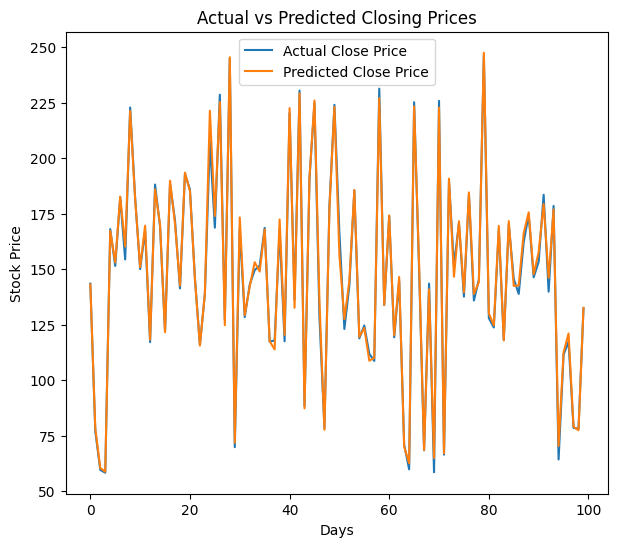

In [9]:
plt.figure(figsize=(7,6))

plt.plot(y_test.values[:100], label='Actual Close Price') # Plot the actual closing prices from the test dataset and display only the first 100 values for better visualization
plt.plot(y_pred[:100], label='Predicted Close Price')

plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend() #Display the legend to distinguish between actual and predicted prices

plt.show()